# **Problem Understanding**: Predicting Introverts From Extroverts
#### The objective of this project is to distinguish between introverts and extroverts based on behavioral and social activity features.

#### This is a binary classification problem, where the target variable (Personality) takes two values:
    Classes:
    - Introvert
    - Extrovert

#### The goal of the analysis is not just to visualize the data, but to identify and quantify which features provide meaningful and measurable separation between the two classes.

### In particular, we aim to determine:

- #### Which features show clear differences between introverts and extroverts
- #### Whether observed differences are consistent and statistically significant
- #### Which features are the strongest indicators of personality type
- #### Whether combinations of features improve class separation

### This analysis will guide the modeling phase by highlighting:
- #### High-signal features
- #### Redundant or weak features
- #### Key behavioral patterns associated with each personality type

In [27]:
import sys
import pandas as pd
from pathlib import Path

# 1. Tell Jupyter where your root folder is so it can find 'src'
# (Path.cwd() gets the notebook's current folder, .parent.parent goes up to the root)
project_root = str(Path.cwd().parent.parent)
if project_root not in sys.path:
    sys.path.append(project_root)

# 2. Import your robust paths from your utils file
# (Change 'your_utils_file' to whatever you actually named the .py file in src/utils/)
from src.utils.paths import RAW_DATA_DIR

# 3. Read the dataset!
# The '/' operator perfectly joins your robust directory path to your file name
# file_path = RAW_DATA_DIR / "C:\\Users\\Lenovo\\Documents\\Facultate\\Semestrul 3\\Predict_Introverts_From_Extroverts\\data\\raw\\train.csv"
file_path = RAW_DATA_DIR / "train.csv"

df = pd.read_csv(file_path)

# View the first few rows to confirm it worked
df.head()


,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


## Data Loading Validation
#### Verify that the dataset was loaded correctly and inspect its basic structure.

In [28]:
# Verificam numele coloanelor si dimensiunea datasetului
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
print("\nTarget values:", df.iloc[:, -1].unique())

Columns: ['id', 'Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency', 'Personality']
Shape: (18524, 9)

Target values: <StringArray>
['Extrovert', 'Introvert']
Length: 2, dtype: str


In [29]:
# Assuming your dataset is already loaded into a variable named 'df'
import pandas as pd

if df.empty:
    print("Warning: The DataFrame is empty.")
else:
    # 1. Extract the raw data types into a DataFrame
    dtypes_df = df.dtypes.reset_index()
    dtypes_df.columns = ['Column', 'Data Type']

    # 2. Create a function to group them into human-readable categories
    def categorize_dtype(dt):
        if pd.api.types.is_numeric_dtype(dt):
            return 'Numeric'
        elif pd.api.types.is_datetime64_any_dtype(dt):
            return 'Datetime'
        elif pd.api.types.is_bool_dtype(dt):
            return 'Boolean'
        else:
            return 'Categorical / Text'

    # Apply the categorization
    dtypes_df['Category'] = df.dtypes.apply(categorize_dtype).values

    # 3. Calculate memory usage for each column (deep=True checks exact string lengths)
    mem_usage = df.memory_usage(deep=True, index=False).reset_index()
    mem_usage.columns = ['Column', 'Memory (Bytes)']

    # Merge the memory info with our dtypes table
    dtypes_df = pd.merge(dtypes_df, mem_usage, on='Column')

    # Convert Bytes to Megabytes for easier reading
    dtypes_df['Memory (MB)'] = (dtypes_df['Memory (Bytes)'] / (1024 * 1024)).round(4)
    dtypes_df = dtypes_df.drop(columns=['Memory (Bytes)'])

    # 4. Sort by Category so all your Numerics and Categoricals are grouped together
    dtypes_df = dtypes_df.sort_values(by=['Category', 'Column'])

    # Set the column name as the index for a cleaner look
    dtypes_df = dtypes_df.set_index('Column')

    # 5. Force Jupyter to render the table beautifully
    display(dtypes_df)

,Data Type,Category,Memory (MB)
Column,,,
Drained_after_socializing,str,Categorical / Text,0.8840
Personality,str,Categorical / Text,1.0246
Stage_fear,str,Categorical / Text,0.8705
Friends_circle_size,float64,Numeric,0.1413
Going_outside,float64,Numeric,0.1413
Post_frequency,float64,Numeric,0.1413
Social_event_attendance,float64,Numeric,0.1413
Time_spent_Alone,float64,Numeric,0.1413
id,int64,Numeric,0.1413


## Observations - Data Types

### The dataset contains 18,524 observations

### It includes both numerical and categorical features that describe social behavior and habits

- #### Numerical features <small>(Time_spent_Alone, Social_event_attendance, Going_outside, Friends_circle_size, Post_frequency)</small> reflect how active or social a person is

- #### Categorical features <small>(Stage_fear, Drained_after_socializing)</small> capture how people feel in social situations

- #### The target variable <small>(Personality)</small> is binary: **Introvert** or **Extrovert**

-  #### All columns have appropriate data types — no obvious issues like numbers stored as text

-  #### Feature types make sense for the problem and allow different types of analysis (numerical vs categorical)

-  #### Even though there are only two categorical features, they are likely very important since they directly describe social discomfort

## Note for Preprocessing

- #### Categorical features will need to be encoded <small>(e.g., Yes/No → 1/0)</small> before modeling

In [41]:
# Assuming your dataset is already loaded into a variable named 'df'

if df.empty:
    print("Warning: The DataFrame is empty.")
else:
    # 1. Calculate counts and percentages
    missing_count = df.isnull().sum()
    missing_percentage = (missing_count / len(df)) * 100

    # 2. Combine into a clean DataFrame
    missing_info = pd.concat(
        [missing_count, missing_percentage],
        axis=1,
        keys=['Missing Count', 'Missing Percentage (%)']
    )

    # 3. Filter out columns that have NO missing data
    missing_info = missing_info[missing_info['Missing Count'] > 0]

    # 4. Sort the worst offenders to the top
    missing_info = missing_info.sort_values(by='Missing Percentage (%)', ascending=False)

    # 5. Round the percentage for a cleaner display
    missing_info['Missing Percentage (%)'] = missing_info['Missing Percentage (%)'].round(2)

    # 6. Force Jupyter to render the table, even inside the 'else' block
    display(missing_info)
    
    # Missingness vs target
for col in df.columns:
    if df[col].isnull().sum() > 0:
        print(f"\n{col}")
        print(df.groupby(df[col].isnull())["Personality"].value_counts(normalize=True))

,Missing Count,Missing Percentage (%)
Stage_fear,1893,10.22
Going_outside,1466,7.91
Post_frequency,1264,6.82
Time_spent_Alone,1190,6.42
Social_event_attendance,1180,6.37
Drained_after_socializing,1149,6.20
Friends_circle_size,1054,5.69



Time_spent_Alone
Time_spent_Alone  Personality
False             Extrovert      0.737856
                  Introvert      0.262144
True              Extrovert      0.763866
                  Introvert      0.236134
Name: proportion, dtype: float64

Stage_fear
Stage_fear  Personality
False       Extrovert      0.754615
            Introvert      0.245385
True        Extrovert      0.606973
            Introvert      0.393027
Name: proportion, dtype: float64

Social_event_attendance
Social_event_attendance  Personality
False                    Extrovert      0.747636
                         Introvert      0.252364
True                     Extrovert      0.620339
                         Introvert      0.379661
Name: proportion, dtype: float64

Going_outside
Going_outside  Personality
False          Extrovert      0.746688
               Introvert      0.253312
True           Extrovert      0.656207
               Introvert      0.343793
Name: proportion, dtype: float64

Drained_after_s

## Observations - Missing Values

- #### Several features have missing values, generally between ~5% and ~10%
- #### No column has enough missing data to justify dropping it
- #### Missing values are spread across multiple features, not concentrated in just one
- #### Overall, the amount of missing data is moderate and manageable without losing much information

### Missingness vs Target

- #### Missing values do not show a strong difference between Introverts and Extroverts
- #### This suggests the missing data is likely random and not biased toward one class
- #### Because of this, standard imputation methods should not introduce significant bias

## Note for Preprocessing

- #### Missing values should be handled before modeling
- #### Numerical features: use mean or median imputation
- #### Categorical features: use the most frequent value (mode)
- #### No column needs to be removed based on the current level of missing data

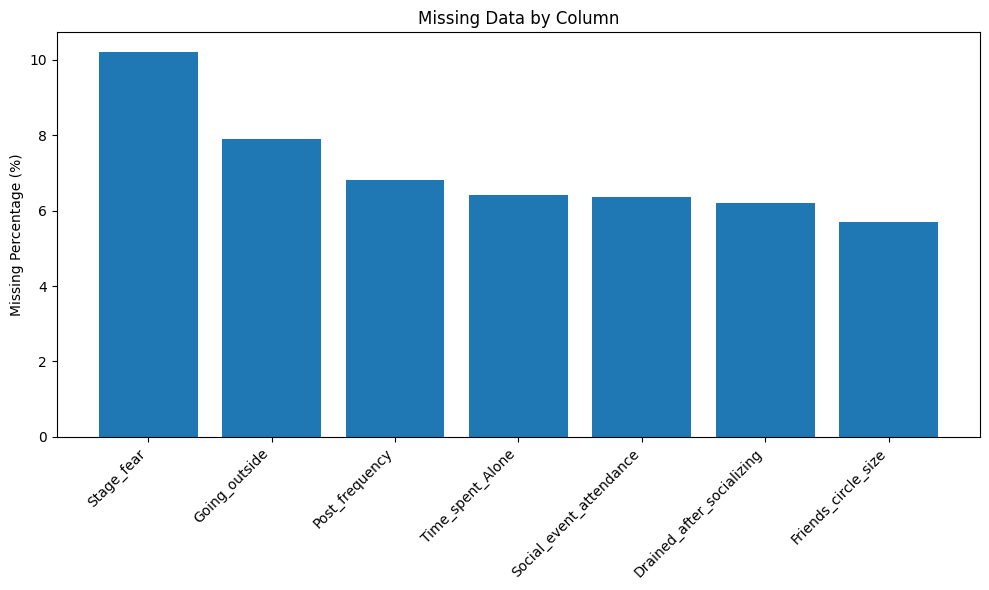

In [42]:
import matplotlib.pyplot as plt

if df.empty:
    print("Warning: The DataFrame is empty.")
else:
    missing_count = df.isnull().sum()
    missing_percentage = (missing_count / len(df)) * 100

    missing_info = pd.concat(
        [missing_count, missing_percentage],
        axis=1,
        keys=['Missing Count', 'Missing Percentage (%)']
    )

    missing_info = missing_info[missing_info['Missing Count'] > 0]
    missing_info = missing_info.sort_values(by='Missing Percentage (%)', ascending=False)
    missing_info['Missing Percentage (%)'] = missing_info['Missing Percentage (%)'].round(2)

    # ---- PLOT ----
    plt.figure(figsize=(10, 6))
    plt.bar(missing_info.index, missing_info['Missing Percentage (%)'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Missing Percentage (%)')
    plt.title('Missing Data by Column')
    plt.tight_layout()
    plt.show()

In [32]:
# Assuming your dataset is already loaded into a variable named 'df'
import numpy as np
import pandas as pd

if df.empty:
    print("Warning: The DataFrame is empty.")
else:
    # 1. Isolate only the numerical columns
    num_cols = df.select_dtypes(include=[np.number]).columns

    if len(num_cols) == 0:
        print("No numerical columns found to analyze for outliers.")
    else:
        outlier_data = []
        total_rows = len(df)

        # 2. Calculate the IQR and bounds for each numerical column
        for col in num_cols:
            # Drop NaNs just for the calculation so math doesn't break
            col_data = df[col].dropna()
            if col_data.empty:
                continue

            Q1 = col_data.quantile(0.25)
            Q3 = col_data.quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # 3. Count how many rows fall outside the bounds
            lower_outliers = (col_data < lower_bound).sum()
            upper_outliers = (col_data > upper_bound).sum()
            total_outliers = lower_outliers + upper_outliers

            # 4. Only keep data for columns that actually have outliers
            if total_outliers > 0:
                outlier_data.append({
                    'Column': col,
                    'Total Outliers': total_outliers,
                    'Outlier Percentage (%)': (total_outliers / total_rows) * 100,
                    'Lower Outliers': lower_outliers,
                    'Upper Outliers': upper_outliers,
                    'Lower Bound': lower_bound,
                    'Upper Bound': upper_bound
                })

        # 5. Combine into a clean DataFrame
        if not outlier_data:
            print("No outliers found in any numerical columns based on the 1.5 * IQR rule.")
        else:
            outlier_info = pd.DataFrame(outlier_data)

            # 6. Sort the columns with the most outliers to the top
            outlier_info = outlier_info.sort_values(by='Outlier Percentage (%)', ascending=False)

            # 7. Round the numbers for a cleaner display
            outlier_info['Outlier Percentage (%)'] = outlier_info['Outlier Percentage (%)'].round(2)
            outlier_info['Lower Bound'] = outlier_info['Lower Bound'].round(4)
            outlier_info['Upper Bound'] = outlier_info['Upper Bound'].round(4)

            # Set the column name as the index to make the table look much cleaner
            outlier_info = outlier_info.set_index('Column')

            # 8. Force Jupyter to render the table beautifully
            display(outlier_info)

,Total Outliers,Outlier Percentage (%),Lower Outliers,Upper Outliers,Lower Bound,Upper Bound
Column,,,,,,
Time_spent_Alone,1653,8.92,0,1653,-3.5,8.5


## Observations - Outliers

- #### Outliers are present only in the <small>Time_spent_Alone</small> feature (~9% of the data)
- #### These are all upper outliers, meaning some individuals report unusually high time spent alone
- #### This likely reflects real behavioral variation rather than data errors

- #### Since outliers are limited to a single feature and not extreme in proportion, they are unlikely to significantly distort the overall analysis
- #### However, they may still influence models that are sensitive to extreme values

## Note for Preprocessing

- #### Consider clipping extreme values for models that are sensitive to outliers

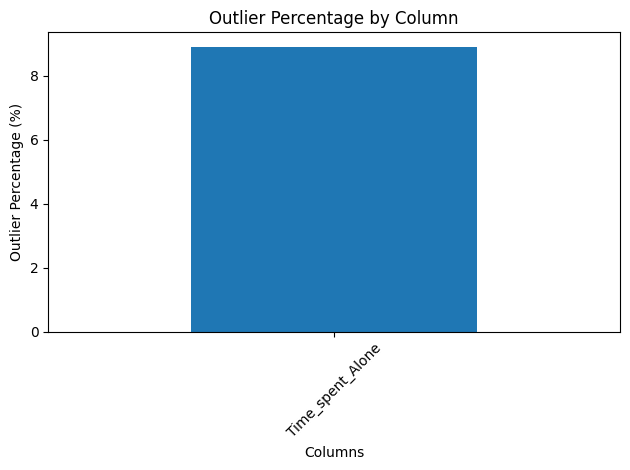

In [33]:
import matplotlib.pyplot as plt

# Ensure it's not empty
if not outlier_info.empty:
    plt.figure()

    outlier_info['Outlier Percentage (%)'].plot(kind='bar')

    plt.title('Outlier Percentage by Column')
    plt.xlabel('Columns')
    plt.ylabel('Outlier Percentage (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

- #### around 9% of values in <small>Time_spent_Alone</small> are outliers (~1,600 rows), which is noticeable but not extreme

In [34]:
# Assuming your dataset is already loaded into a variable named 'df'
import numpy as np
import pandas as pd

if df.empty:
    print("Warning: The DataFrame is empty.")
else:
    # 1. Isolate only the numerical columns
    num_cols = df.select_dtypes(include=[np.number]).columns

    if len(num_cols) == 0:
        print("No numerical columns found to analyze for skewness.")
    else:
        # 2. Calculate skewness using pandas built-in function
        # We drop NaNs temporarily just for the calculation
        skew_vals = df[num_cols].apply(lambda x: x.dropna().skew())

        # 3. Create a clean DataFrame
        skew_info = pd.DataFrame({'Skewness': skew_vals})

        # 4. Add a human-readable interpretation
        def interpret_skew(val):
            if pd.isna(val):
                return "Not enough data"
            elif abs(val) > 1.0:
                return "Highly Skewed (Consider log transformation)"
            elif abs(val) > 0.5:
                return "Moderately Skewed"
            else:
                return "Fairly Symmetrical"

        skew_info['Interpretation'] = skew_info['Skewness'].apply(interpret_skew)

        # 5. Sort by the most extreme skewness (absolute value)
        skew_info['Absolute Skew'] = skew_info['Skewness'].abs()
        skew_info = skew_info.sort_values(by='Absolute Skew', ascending=False)
        skew_info = skew_info.drop(columns=['Absolute Skew']) # Drop the helper column

        # 6. Clean up the display
        skew_info['Skewness'] = skew_info['Skewness'].round(3)
        skew_info.index.name = 'Column'

        # 7. Force Jupyter to render the table beautifully
        display(skew_info)

,Skewness,Interpretation
Column,,
Time_spent_Alone,1.134,Highly Skewed (Consider log transformation)
Going_outside,-0.367,Fairly Symmetrical
Social_event_attendance,-0.229,Fairly Symmetrical
Post_frequency,-0.059,Fairly Symmetrical
Friends_circle_size,-0.052,Fairly Symmetrical
id,0.000,Fairly Symmetrical


## Observations - Skewness

- #### Most numerical features are fairly symmetrical and do not show significant skewness
- #### <small>Time_spent_Alone</small> is the only feature with noticeable skew (~1.13), indicating a right-skewed distribution
- #### This suggests that a subset of individuals report unusually high time spent alone, which aligns with the outlier findings

- #### Since skewness is limited to a single feature, it is unlikely to impact the overall analysis significantly

## Note for Preprocessing

- #### Apply transformations <small>(e.g., log or Box-Cox)</small> if using models that are sensitive to skewed data

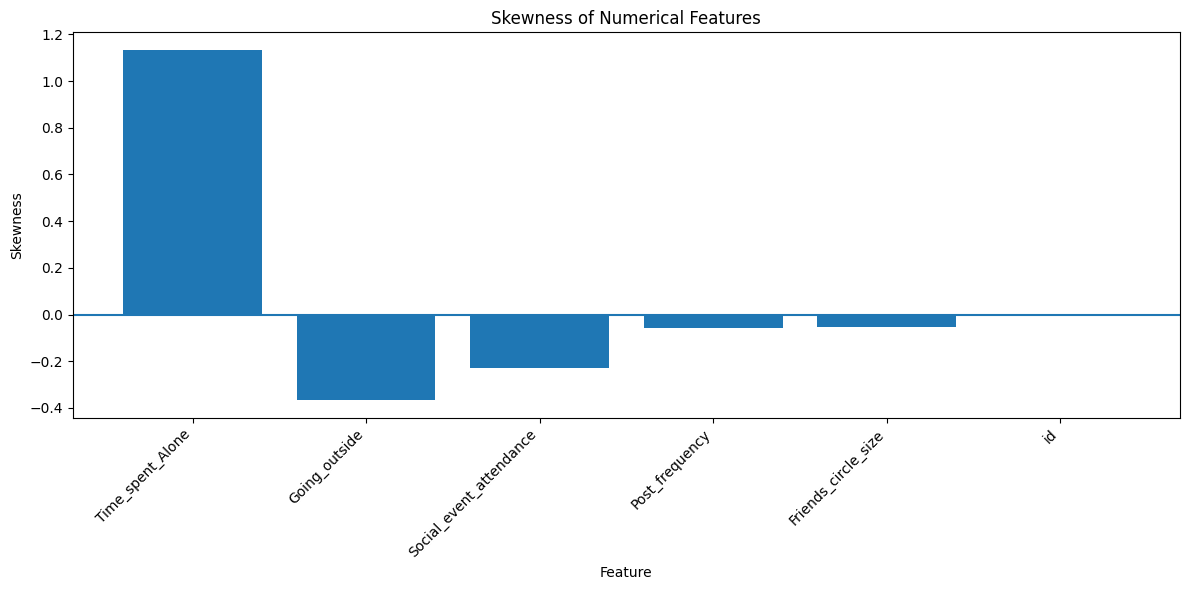

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(skew_info.index, skew_info['Skewness'])

# Reference line at 0 (perfect symmetry)
plt.axhline(0)

# Labels and title
plt.xlabel("Feature")
plt.ylabel("Skewness")
plt.title("Skewness of Numerical Features")

# Rotate column names for readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Target distribution:
Personality
Extrovert    13699
Introvert     4825
Name: count, dtype: int64

Target distribution (%):
Personality
Extrovert    74.0
Introvert    26.0
Name: proportion, dtype: float64


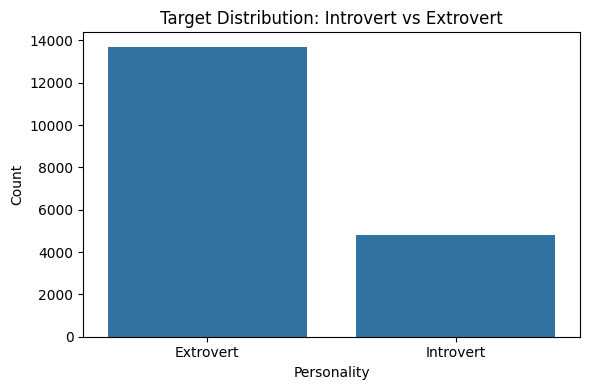

In [36]:
# Target distribution analysis
import seaborn as sns
import matplotlib.pyplot as plt

target_col = "Personality"

print("Target distribution:")
print(df[target_col].value_counts())
print("\nTarget distribution (%):")
print(df[target_col].value_counts(normalize=True).round(3) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=df)
plt.title("Target Distribution: Introvert vs Extrovert")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Observations - Target Distribution

- #### The dataset is clearly imbalanced:
  - #### Extroverts make up around 74% of the data (~13,700 samples)
  - #### Introverts make up around 26% (~4,800 samples)

- #### This means the model will naturally see more extrovert examples during training
- #### Without proper handling, models may become biased toward predicting the majority class (Extrovert)

- #### Accuracy alone may be misleading in this case, as a model could achieve high accuracy by favoring the majority class

## Note for Modeling

- #### Use stratified train/test splits to preserve class distribution
- #### Consider class weighting or resampling techniques to handle imbalance

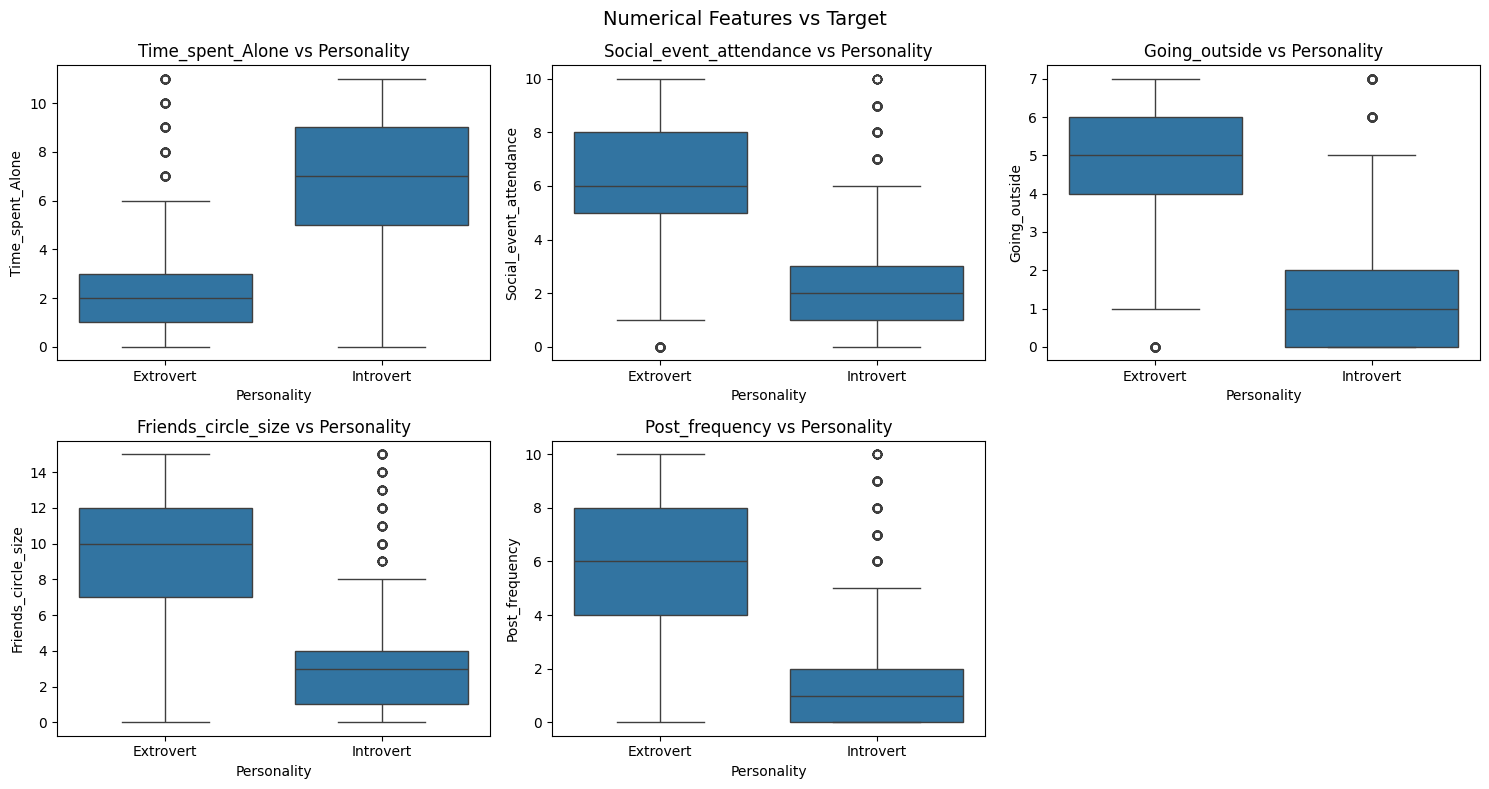

In [37]:
# Relationship between numerical features and target
num_cols = ['Time_spent_Alone', 'Social_event_attendance', 
            'Going_outside', 'Friends_circle_size', 'Post_frequency']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=target_col, y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs Personality")

# Hide the empty 6th subplot
axes[5].set_visible(False)

plt.suptitle("Numerical Features vs Target", fontsize=14)
plt.tight_layout()
plt.show()

## Observations - Numerical Features vs Target

- #### All numerical features show clear separation between Introverts and Extroverts

- #### <small>Time_spent_Alone</small>:
  - #### Introverts spend significantly more time alone
  - #### Extroverts are clustered at lower values

- #### <small>Social_event_attendance</small>, <small>Going_outside</small>, <small>Post_frequency</small>:
  - #### Extroverts consistently have higher values
  - #### Introverts are concentrated at lower ranges

- #### <small>Friends_circle_size</small>:
  - #### Extroverts have noticeably larger social circles
  - #### Introverts are grouped at much smaller values

- #### Across all features, there is relatively low overlap between the two classes
- #### This indicates strong discriminatory power for all numerical variables

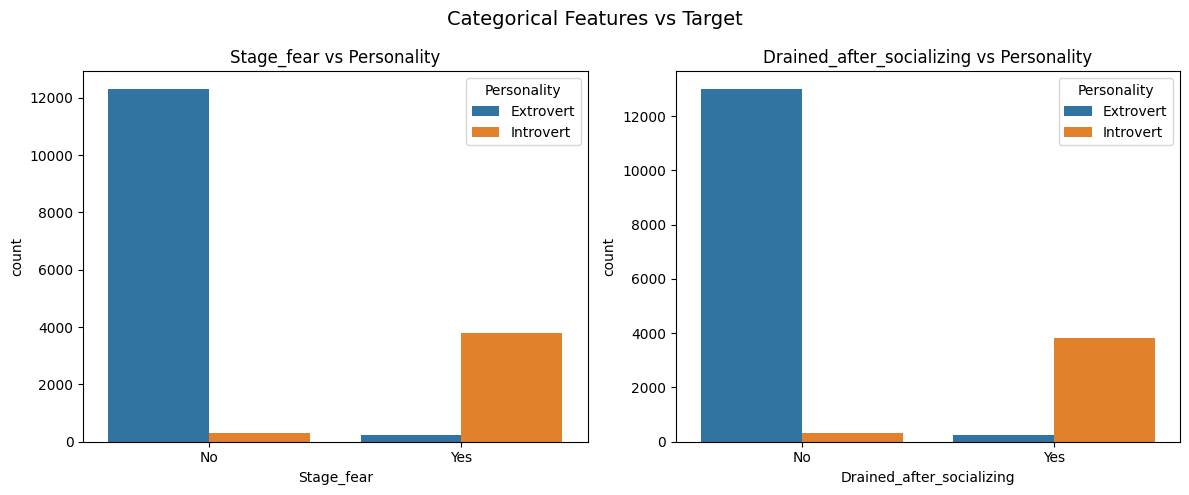

In [38]:
# Relationship between categorical features and target
cat_cols = ['Stage_fear', 'Drained_after_socializing']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue=target_col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs Personality")
    axes[i].set_xlabel(col)
    axes[i].legend(title="Personality")

plt.suptitle("Categorical Features vs Target", fontsize=14)
plt.tight_layout()
plt.show()

## Observations - Categorical Features vs Target

- #### Both categorical features show extremely strong separation between Introverts and Extroverts

- ### <small>Stage_fear</small>:
  - #### Individuals with stage fear (“Yes”) are predominantly Introverts
  - #### Individuals without stage fear (“No”) are overwhelmingly Extroverts

- ### <small>Drained_after_socializing</small>:
  - #### Those who feel drained after socializing (“Yes”) are almost entirely Introverts
  - #### Those who do not (“No”) are mostly Extroverts

- #### The separation is very clear, with minimal overlap between the two classes
- #### These features act as direct indicators of personality type and are likely among the strongest predictors in the dataset

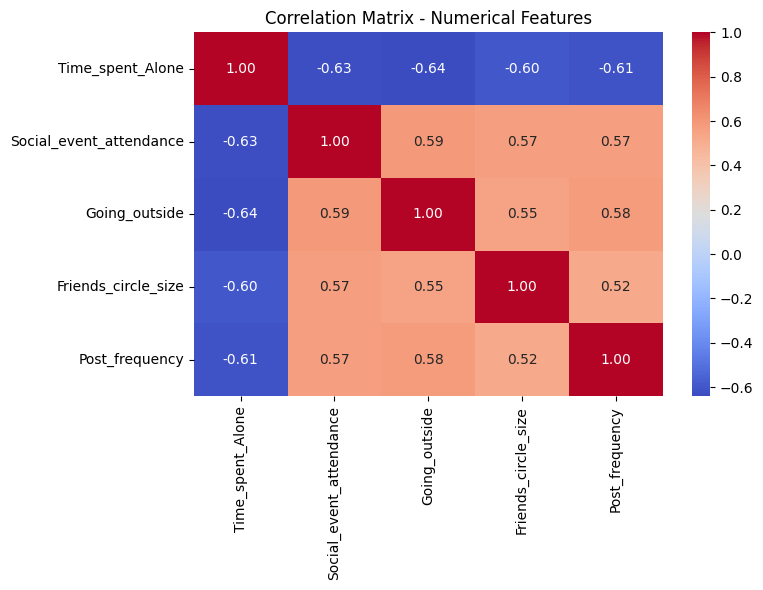

In [39]:
# Correlation matrix (numerical features only)
num_df = df[num_cols]

plt.figure(figsize=(8, 6))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix - Numerical Features")
plt.tight_layout()
plt.show()

## Observations - Correlation (Numerical Features)

- #### <small>Time_spent_Alone</small> shows strong negative correlation with all other features (~ -0.60 to -0.64)
  - #### This indicates that individuals who spend more time alone tend to engage less in social activities

- #### The remaining features <small>(Social_event_attendance, Going_outside, Friends_circle_size, Post_frequency)</small> are moderately positively correlated (~0.52 to 0.59)
  - #### These features capture related aspects of social behavior and tend to increase together

- #### No extremely high correlations are present, meaning there is no severe multicollinearity in the dataset

- #### While some features are related, they still provide complementary information rather than being exact duplicates

## Note for Preprocessing

- #### No features need to be removed based on correlation
- #### All features can be retained, as they provide related but not redundant information

## Final Conclusions
- #### Overall, both numerical and categorical features consistently separate Introverts from Extroverts, indicating that personality differences are strongly reflected in observable behavioral patterns

### Target Distribution
- #### Dataset is imbalanced: 74% Extrovert vs 26% Introvert
- #### This is important — modeling team must handle this imbalance
- #### Recommended: use class_weight='balanced' or stratified sampling

Numerical Features vs Personality (Boxplots)

- #### <small>**Time_spent_Alone**</small>: Introverts spend significantly more time alone — clear separation
- #### <small>**Social_event_attendance**</small>: Extroverts attend far more social events — clear separation
- #### <small>**Going_outside**</small>: Extroverts go outside more frequently
- #### <small>**Friends_circle_size**</small>: Extroverts have noticeably larger social circles
- #### <small>**Post_frequency**</small>: Extroverts post more frequently

- #### All numerical features show consistent separation between the two classes and are useful for prediction

### Categorical Features vs Personality
- #### **Stage_fear**</small>: Almost all people with stage fear (Yes) are Introverts — extremely strong signal
- #### **Drained_after_socializing**</small>: Almost all people drained after socializing (Yes) are Introverts — extremely strong signal
- #### Both categorical features are among the most important in the dataset

### Correlation Matrix
- #### <small>**Time_spent_Alone**</small> is negatively correlated with all other features (-0.60 to -0.64)
- #### <small>**Social_event_attendance, Going_outside, Friends_circle_size, Post_frequency**</small> are positively correlated with each other (0.52 to 0.59)
- #### No extreme multicollinearity — all features can be kept
- #### While features are moderately correlated, they capture related but distinct aspects of social behavior, so keeping all features is justified

## Recommendations for Preprocessing Team
- #### Handle missing values: use median for numerical, mode for categorical
- #### Encode <small>**Stage_fear**</small> and <small>**Drained_after_socializing**</small> (Yes/No → 1/0)
- #### All features are useful — do not drop any
- #### Consider scaling numerical features for non-tree-based models

## Recommendations for Modeling Team
- #### Dataset is imbalanced (74/26) — use stratified split and class weights
- #### <small>**Stage_fear**</small> and <small>**Drained_after_socializing**</small> are the strongest predictors
- #### Tree-based models (XGBoost, LightGBM) recommended — robust to skewness and outliers
- #### All 7 features should be included in the model